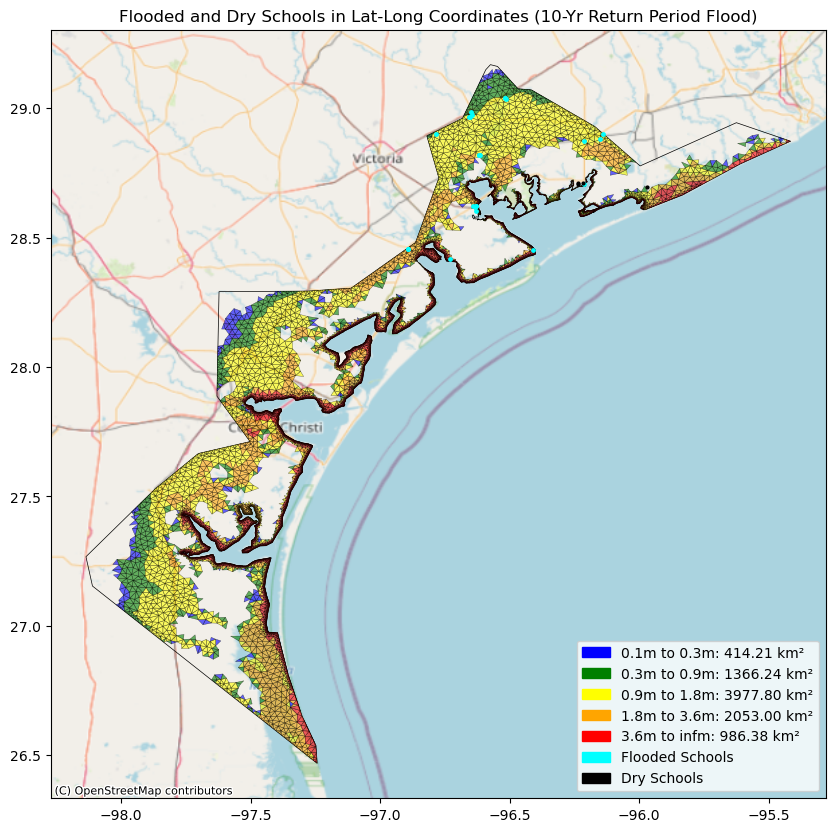

Depth range 0.1m to 0.3m: 414.21 square kilometers
Depth range 0.3m to 0.9m: 1366.24 square kilometers
Depth range 0.9m to 1.8m: 3977.80 square kilometers
Depth range 1.8m to 3.6m: 2053.00 square kilometers
Depth range 3.6m to infm: 986.38 square kilometers


In [10]:
import pandas as pd
import numpy as np
import mikeio
import geopandas as gpd
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\10-yr return period storm CC.m21fm - Result Files\10-yr_CC_Stat.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth") 

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load school shapefile and set the same CRS (EPSG:32614)
shape_path2 = r"D:\Phd Research\Critical Infrastructure\Shape file\Schools2019to2020_372503062685561240.zip"
school_point = gpd.read_file(shape_path2).to_crs(32614)
school_intersect = gpd.overlay(school_point, land_boundary, how='intersection')

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges
depth_ranges = [
    (0.1, 0.3),
    (0.3, 0.9),
    (0.9, 1.8),
    (1.8, 3.6),
    (3.6, np.inf)
]

# Colors for plotting
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

for low, high in depth_ranges:
    # Identify elements within the depth range
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    
    flooded_polygons = []
    for elem_idx in flooded_elements:
        nodes = element_table[elem_idx]
        coords = node_coordinates[nodes]
        polygon = Polygon(coords)
        flooded_polygons.append(polygon)
    
    # Create a GeoDataFrame for the flooded polygons
    flooded_area_gdf = gpd.GeoDataFrame(
        {'geometry': flooded_polygons},
        crs="EPSG:32614"  # Ensure CRS matches
    )
    
    # Clip the polygons with the land boundary shapefile
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate the total area for this depth range
    total_area = flooded_area_clipped.area.sum()
    total_area_by_range.append(total_area / 1e6)  # Convert to square kilometers
    
    flooded_polygons_by_range.append(flooded_area_clipped)

# Reproject land boundary and school points to Lat-Long (WGS 84)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
school_intersect_latlong = school_intersect.to_crs(epsg=4326)

# Reproject flooded polygons to Lat-Long (WGS 84)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]

# Convert flooded and dry schools to Lat-Long (WGS 84)
flooded_schools_gdf = gpd.GeoDataFrame(geometry=flooded_schools, crs="EPSG:32614")
dry_schools_gdf = gpd.GeoDataFrame(geometry=dry_schools, crs="EPSG:32614")
flooded_schools_gdf_latlong = flooded_schools_gdf.to_crs(epsg=4326)
dry_schools_gdf_latlong = dry_schools_gdf.to_crs(epsg=4326)

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry schools in Lat-Long
flooded_schools_gdf_latlong.plot(ax=ax, color='cyan', marker='o', label='Flooded Schools', markersize=6, zorder=5)
dry_schools_gdf_latlong.plot(ax=ax, color='black', marker='o', label='Dry Schools', markersize=4, zorder=5)

# Plot each depth range with a different color in Lat-Long
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='black', linewidth=0.3)

# Add basemap in Lat-Long
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)

# Add a legend
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=color, label=f'{low}m to {high}m: {area:.2f} km²') 
    for (low, high), color, area in zip(depth_ranges, colors, total_area_by_range)
] + [
    mpatches.Patch(color='cyan', label='Flooded Schools'),
    mpatches.Patch(color='black', label='Dry Schools')
]
ax.legend(handles=legend_patches, loc='lower right')

plt.title('Flooded and Dry Schools in Lat-Long Coordinates (10-Yr Return Period Flood)')
plt.show()

# Print the area for each range
for (low, high), area in zip(depth_ranges, total_area_by_range):
    print(f"Depth range {low}m to {high}m: {area:.2f} square kilometers")



In [7]:
num_flooded_schools = len(flooded_schools_gdf)
num_dry_schools = len(dry_schools_gdf)
total_schools = len(school_intersect)

# Calculate the percentages
percent_flooded = (num_flooded_schools / total_schools) * 100
percent_dry = (num_dry_schools / total_schools) * 100

# Print the number and percentage of flooded and dry schools
print(f"Number of flooded schools: {num_flooded_schools}")
print(f"Number of dry schools: {num_dry_schools}")
print(f"Percentage of flooded schools: {percent_flooded:.2f}%")
print(f"Percentage of dry schools: {percent_dry:.2f}%")

# Number of flooded and dry fire stations
num_flooded_fire = len(flooded_fire_gdf)
num_dry_fire = len(dry_fire_gdf)
total_fire = len(fire_intersect)

# Number of flooded and dry hospitals
num_flooded_hos = len(flooded_hos_gdf)
num_dry_hos = len(dry_hos_gdf)
total_hos = len(hos_intersect)

# Number of flooded and dry shelters
num_flooded_shelter = len(flooded_shelter_gdf)
num_dry_shelter = len(dry_shelter_gdf)
total_shelter = len(shelter_intersect)

# Calculate percentages for fire stations
percent_flooded_fire = (num_flooded_fire / total_fire) * 100
percent_dry_fire = (num_dry_fire / total_fire) * 100

# Calculate percentages for hospitals
percent_flooded_hos = (num_flooded_hos / total_hos) * 100
percent_dry_hos = (num_dry_hos / total_hos) * 100

# Calculate percentages for shelters
percent_flooded_shelter = (num_flooded_shelter / total_shelter) * 100
percent_dry_shelter = (num_dry_shelter / total_shelter) * 100

# Print the number and percentage of flooded and dry fire stations
print(f"Number of flooded fire stations: {num_flooded_fire}")
print(f"Number of dry fire stations: {num_dry_fire}")
print(f"Percentage of flooded fire stations: {percent_flooded_fire:.2f}%")
print(f"Percentage of dry fire stations: {percent_dry_fire:.2f}%")

# Print the number and percentage of flooded and dry hospitals
print(f"Number of flooded hospitals: {num_flooded_hos}")
print(f"Number of dry hospitals: {num_dry_hos}")
print(f"Percentage of flooded hospitals: {percent_flooded_hos:.2f}%")
print(f"Percentage of dry hospitals: {percent_dry_hos:.2f}%")

# Print the number and percentage of flooded and dry shelters
print(f"Number of flooded shelters: {num_flooded_shelter}")
print(f"Number of dry shelters: {num_dry_shelter}")
print(f"Percentage of flooded shelters: {percent_flooded_shelter:.2f}%")
print(f"Percentage of dry shelters: {percent_dry_shelter:.2f}%")


Number of flooded schools: 24
Number of dry schools: 4
Percentage of flooded schools: 85.71%
Percentage of dry schools: 14.29%
Number of flooded fire stations: 16
Number of dry fire stations: 5
Percentage of flooded fire stations: 76.19%
Percentage of dry fire stations: 23.81%
Number of flooded hospitals: 2
Number of dry hospitals: 1
Percentage of flooded hospitals: 66.67%
Percentage of dry hospitals: 33.33%
Number of flooded shelters: 7
Number of dry shelters: 5
Percentage of flooded shelters: 58.33%
Percentage of dry shelters: 41.67%


In [28]:
k = school_intersect.itertuples()
